# SNR Model Validation
This repo aims to demonstrate the effeciveness of our Ray-Tracing-based Signal-to-Noise Ratio (SNR) model (from NVIDIA Sionna RT) compared against traditional path loss models like the one found in the AERPAW digital twin.

## Our Process
* We first gather data from a sample AERPAW experiment demonstration how their path channel model is agnostic to building and land topography
* Then we run our digital twin, which computes SNR using a ray-tracing model, on the same trajectory and record its SNR predictions.
* Finally, we visualize the data to show that our model is accurate to the path channel model in line-of-sight (LoS) scenarios, but improves performance in non-LoS and diffraction cases when faced with substantive building topography

### Data Gathering
* We create a sample experiment in the Lake Wheeler AERPAW environment using Lake Wheeler Fixed Node 1 (LW1) and an AERPAW Portable Node (UAV)
* We also construct a low-flying UAV trajectory that circumscribes the NCSU Animal Health Building, with partially LoS paths and partially non-LoS paths to LW1
* We run this experiment in the AERPAW simulated environment, and record the SNR calculated by their path channel model, as well as UAV position over time

![UAV Trajectory](assets/LakeWheelerExperimentMap.png)

### Data Processing and Cleaning
* We take the data from the AERPAW simulation and parse it into a usable form
* We also clean some of the edge conditions from the data and align the positions and SNR values over time

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_time(time_string):
    """
    Parses the time since the start of the day in seconds
    Truncated to the nearest second
    """
    time_string = time_string.strip("]").strip("[")
    tokens = time_string.split(":")
    return int(tokens[0]) * 3600 + int(tokens[1]) * 60 + int(float(tokens[2]))


def parse_snr(path):
    """
    Returns a dictionary of time vs. SNR average every second
    """
    snrs = {}
    with open(path, "r") as f:
        for line in f.readlines():
            tokens = line.split()
            time = parse_time(tokens[1])
            snr = float(tokens[3])

            if time in snrs.keys():
                snrs[time].append(snr)
            else:
                snrs[time] = [snr]
    
    # Averaging each row
    for time in snrs.keys():
        snrs[time] = np.average(snrs[time])

    return snrs


def parse_positions(path):
    """
    Returns a dictionary of time vs. position for every second
    """
    positions = {}

    with open(path, "r") as f:
        for line in f.readlines():
            tokens = line.split(",")
            position = [float(tokens[2]), float(tokens[1]), float(tokens[3])]
            time = parse_time(tokens[11].split()[1])
            
            positions[time] = position
    
    return positions

In [2]:
snrs = parse_snr("experiment_data/2025-10-19_16_13_57_snr_log.txt")
positions = parse_positions("experiment_data/2025-10-19_16_13_57_vehicleOut.txt")

print(f"Positions go from time {min(positions.keys())} to {max(positions.keys())}")
print(f"SNRs go from time {min(snrs.keys())} to {max(snrs.keys())}")
print(f"Stationary SNR values (truncated): {[snrs[i] for i in range(max(positions.keys()), max(snrs.keys()))]}")

Positions go from time 58442 to 58658
SNRs go from time 58453 to 58669
Stationary SNR values (truncated): [2.3256171645161294, -2.07965864, -0.15812562096774185, 0.2537143903333333, 7.017023441935484, 8.920343229999999, 10.360343516129033, 8.29336683, 6.35087483125, 6.805595613333335, 5.82976633548387]


In [3]:
# Truncate the SNR values, because it's just noise after that point, then put all the data in a dataframe
df = pd.DataFrame()
df.insert(0, "Time", list(set(positions.keys()).intersection(set(snrs.keys())))) 
df.insert(1, "SNR", [snrs[i] for i in df["Time"]])
series = ["Lat", "Lon", "Alt"]
for i in range(len(series)):
    df.insert(i + 2, series[i], [positions[j][i] for j in df["Time"]])
print(df.head(5))

    Time        SNR        Lat        Lon    Alt
0  58453  -3.325757  35.727482 -78.696275 -0.017
1  58454   2.445728  35.727482 -78.696275 -0.017
2  58455  14.501149  35.727482 -78.696275 -0.017
3  58456   7.089249  35.727482 -78.696275 -0.017
4  58457   2.456117  35.727482 -78.696275 -0.017


### Visualizing Distance
* Because the path channel model primary works off of distance, it can be useful to see how a distance-based approximation compares with the AERPAW model
* This also helpes ensure that our position and SNR data is aligned

In [4]:
# position of Lake Wheeler Node 1
LW1 = [35.72750947, -78.69595810, 5]

import math
R = 6371000  # mean Earth radius

def compute_dist(pos1, pos2):
    """
    Compute the distance in meters between two points [lat, lon, alt] where alt is in meters.
    Code from DeepSeek for speed
    
    Args:
        pos1: List or tuple of [latitude1, longitude1, altitude1] in degrees and meters
        pos2: List or tuple of [latitude2, longitude2, altitude2] in degrees and meters
    
    Returns:
        float: Distance in meters between the two points
    """
    
    # Extract coordinates
    lat1, lon1, alt1 = pos1
    lat2, lon2, alt2 = pos2
    
    # Convert degrees to radians
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    # Differences in coordinates
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    # Haversine formula for horizontal distance
    a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    horizontal_distance = R * c
    
    # Altitude difference
    dalt = alt2 - alt1
    
    # Total 3D distance using Pythagorean theorem
    total_distance = math.sqrt(horizontal_distance**2 + dalt**2)
    
    return total_distance

df.insert(5, "Distance", [compute_dist(positions[i], LW1) for i in df["Time"]])
print(df.head())

    Time        SNR        Lat        Lon    Alt   Distance
0  58453  -3.325757  35.727482 -78.696275 -0.017  29.172863
1  58454   2.445728  35.727482 -78.696275 -0.017  29.172863
2  58455  14.501149  35.727482 -78.696275 -0.017  29.172863
3  58456   7.089249  35.727482 -78.696275 -0.017  29.172863
4  58457   2.456117  35.727482 -78.696275 -0.017  29.172863


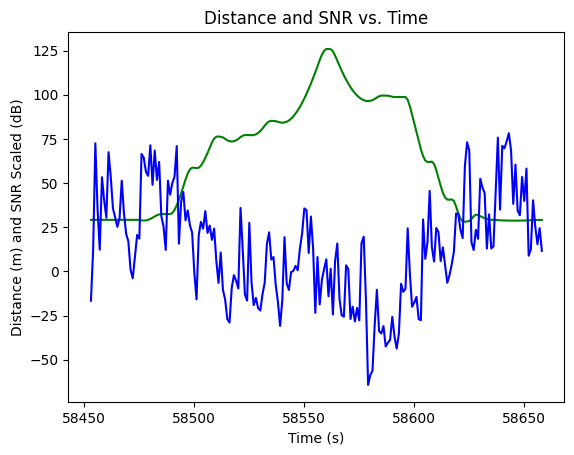

In [5]:
plt.plot(df["Time"], df["Distance"], color="green")
plt.plot(df["Time"], df["SNR"] * 5, color="blue")
plt.title("Distance and SNR vs. Time")
plt.xlabel("Time (s)")
plt.ylabel("Distance (m) and SNR Scaled (dB)")
plt.show()

In [6]:
# Converting to local coordinates

LAUNCH = np.array([35.727482, -78.696275, 0])


OFFSET = [-130, 50, 25]  # Offset in meters to compensate for reference frame alignment
def get_local(pos, launch):
    return np.array([2 * R * np.sin((pos[0] - launch[0]) * np.pi / 360) + OFFSET[0], 
                    -2 * R * np.sin((pos[1] - launch[1]) * np.pi / 360) + OFFSET[1], 
                    pos[2] + OFFSET[2]])

# Adding local coordinates
series = ["X", "Y", "Z"]
for i in range(len(series)):
    df.insert(6 + i, series[i], [get_local(positions[j], LAUNCH)[i] for j in df["Time"]])

print(df.head())

    Time        SNR        Lat        Lon    Alt   Distance           X  \
0  58453  -3.325757  35.727482 -78.696275 -0.017  29.172863 -129.966642   
1  58454   2.445728  35.727482 -78.696275 -0.017  29.172863 -129.966642   
2  58455  14.501149  35.727482 -78.696275 -0.017  29.172863 -129.966642   
3  58456   7.089249  35.727482 -78.696275 -0.017  29.172863 -129.966642   
4  58457   2.456117  35.727482 -78.696275 -0.017  29.172863 -129.966642   

           Y       Z  
0  49.966642  24.983  
1  49.966642  24.983  
2  49.966642  24.983  
3  49.966642  24.983  
4  49.966642  24.983  


### Incorporating Geospatial Data
* To facilitate the ray tracing, we bring in building and terrain data from OpenStreetMaps, imported through Blender
* Before using this model, we have to make sure that our coordinate systems are aligned correctly

In [7]:
import sys
import tensorflow as tf
sys.path.append("../..")

from src.EnvironmentFramework import Environment, GroundUser
from src.AERPAWEnvironment import AERPAWEnv

# Checking for GPU Support
if len(tf.config.list_physical_devices("GPU")) > 0:
    print("GPU Found")
else:
    print("No GPU Detected...")

# Test visualization without any scene objects
buildings = "experiment_data/LakeWheelerBuildings/lake_wheeler_road_aerpaw.xml"
test_env = AERPAWEnv(scene_path=buildings,
                uavs={}, ground_users={}, base_stations={}, temperature=300)
test_env.visualize()

2025-10-19 23:51:37.960412: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-19 23:51:37.971269: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760932297.983602  200936 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760932297.987380  200936 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760932297.996950  200936 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU Found


### Creating Radio Devices
* Since this is a simple situation with only a single transmitter and receiver, we only need to instantiate those two devices
* We start the UAV at launch, and then move it around the simulation later based on the AERPAW trajectory data

In [23]:
# We're leaving in only the parameters that are relavent to this experiment, the other ones are left to defaults
BS_SIGNAL_POWER = 2
BS_BANDWIDTH = 3300  # 3.3GHz from the AERPAW manual
UAV_SIGNAL_POWER = 1
UAV_BANDWIDTH = 3300

base_station = [
    {
    "device_type": "tx",
    "position": get_local(LW1, LAUNCH),
    "color": np.array([0, 1, 0]),
    "bandwidth": BS_BANDWIDTH,
    "signal_power": BS_SIGNAL_POWER
    }
]

deadzone = np.arange(65, 100)

uav = [
    {
    "device_type": "rx",
    "position": np.array([df["X"][i], df["Y"][i], df["Z"][i]]),
    "velocity": np.zeros(3),
    "color": np.array([0, 0, 1]) if not i in deadzone else np.array([1, 0, 0]),
    "bandwidth": UAV_BANDWIDTH,
    "signal_power": UAV_SIGNAL_POWER
    } for i in range(len(df))
]

# This should visualize the test environment and the trajectory with the non-LoS in red
test_trajectory = AERPAWEnv(scene_path=buildings, uavs=uav, ground_users={}, base_stations=base_station, temperature=300)
test_trajectory.visualize()

In [24]:
# Creating the real environment
uav = [
    {
    "device_type": "rx",
    "position": np.array([df["X"][0], df["Y"][0], df["Z"][0]]),
    "velocity": np.zeros(3),
    "color": np.array([0, 0, 1]),
    "bandwidth": UAV_BANDWIDTH,
    "signal_power": UAV_SIGNAL_POWER
    }
]

env = AERPAWEnv(scene_path=buildings, uavs=uav, ground_users={}, base_stations=base_station, temperature=300)

In [25]:
# Computing Ray-tracing SNR Data

MAX_DEPTH = 3
NUM_SAMPLES = 1000000

snr_computed = []
plot = False

for i in range(len(df)):
    print(f"Computing for time: {df["Time"][i]}")
    position = np.array([df["X"][i], df["Y"][i], df["Z"][i]])
    env.moveAbsUAV(0, position, np.zeros(3))
    
    # Computing and storing the SNR values
    snr = env.getSNR(max_depth=MAX_DEPTH, num_samples=NUM_SAMPLES, 
                      sampling_frequency=1.0, mode="gpu", los=False, 
                      reverse=False)
    snr_computed.append(snr["uav0"][f'bs0'])
    
    # Saving after each iteration in case we end early
    np.savetxt("experiment_data/snr_computed.csv", np.array(snr_computed), delimiter=',')
    
    if plot:
        # Plotting the current state
        plt.scatter(position[0], position[1], color="green")
        plt.scatter(BASE_STATIONS_XYA[:, 0], BASE_STATIONS_XYA[:, 1], color="red")
        plt.title(f"Environment State at Time {i + 1}")
        plt.xlabel("X Position (meters)")
        plt.ylabel("Y Position (meters)")
        plt.savefig(f"../data/aerpaw/EnvironmentComparison/state{i}.png")

print(np.array(snr_computed).astype(np.float64))

Computing for time: 58453
Computing for time: 58454
Computing for time: 58455
Computing for time: 58456
Computing for time: 58457
Computing for time: 58458
Computing for time: 58459
Computing for time: 58460
Computing for time: 58461
Computing for time: 58462
Computing for time: 58463
Computing for time: 58464
Computing for time: 58465
Computing for time: 58466
Computing for time: 58467
Computing for time: 58468
Computing for time: 58469
Computing for time: 58470
Computing for time: 58471
Computing for time: 58472
Computing for time: 58473
Computing for time: 58474
Computing for time: 58475
Computing for time: 58476
Computing for time: 58477
Computing for time: 58478
Computing for time: 58479
Computing for time: 58480
Computing for time: 58481
Computing for time: 58482
Computing for time: 58483
Computing for time: 58484
Computing for time: 58485
Computing for time: 58486
Computing for time: 58487
Computing for time: 58488
Computing for time: 58489
Computing for time: 58490
Computing fo

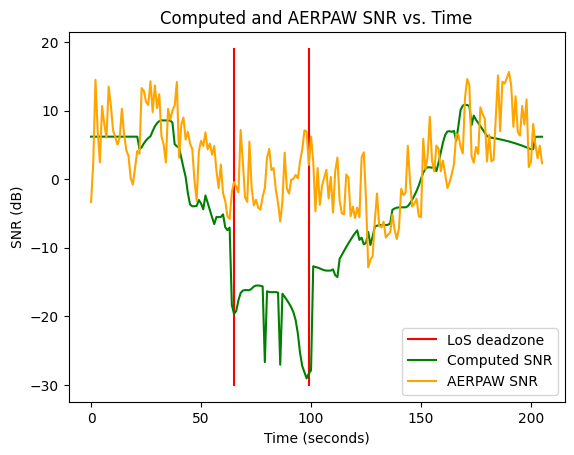

In [41]:
computed_snr = np.loadtxt("experiment_data/snr_computed.csv", delimiter=',')

# Plotting vertical lines for estimated non-LoS zone
plt.plot(np.full(50, deadzone[0]), np.arange(-30, 20), color="red")
plt.plot(np.full(50, deadzone[-1]), np.arange(-30, 20), color="red", label="LoS deadzone")

# Plotting computed and known SNR
plt.plot(computed_snr, color="green", label="Computed SNR")
plt.plot(df["SNR"], color="orange", label="AERPAW SNR")
plt.xlabel("Time (seconds)")
plt.ylabel("SNR (dB)")
plt.title("Computed and AERPAW SNR vs. Time")
plt.legend(loc="lower right")
plt.show()

## Key Takeaways
* The primary observation from this data is that inside the LoS deadzone, the AERPAW path channel model and our ray-tracing model differ quite substantially.
* The path channel model doesn't take the buildings into consideration at all in its SNR calculation
* Outside the LoS deadzone, the ray tracing model and the path channel model are quite similar, showing similar correlations with distance
* In the LoS deadzone, the ray tracing model is relying on diffraction to estimate the path quality, which explains why the is a hump as the UAV gets close to the opposite edge of the deadzone at its eastmost waypoint